# Panic Project (DHLAB) - Data Analysis

author:  `@cyshin971`  

date:    `2025-08-20`  

version: `1.0`

> version `1.0`: derived from `data_analysis.ipynb` version `3.1`

In [1]:
version = '1-0'

# 📚 | Import Libraries 

- `python` (`3.10`)
- `pandas`  
- `numpy`
- `json`
- `matplotlib`

In [2]:
import config as cfg
import logging

import pandas as pd
import matplotlib.pyplot as plt
logging.getLogger('matplotlib').setLevel(logging.WARNING)

from library.pandas_utils import move_column, aggregate_by_column, create_empty_df, read_csv
from library.text_utils import save_as_csv
from library.json_utils import save_dict_to_file, load_dict_from_file
from library.path_utils import get_file_path

# ⚙️ | Settings

In [3]:
days_before_panic = 2
manual_proc_data_filename = f'panic_severity_multi_proc_data_{days_before_panic}days_3-1(12h)'

# 📁 | Path Variables 

In [4]:
DATA_PATH = "./data"
TMP_PATH = "./_tmp"
OUT_PATH = TMP_PATH
file_desc = ""

try:
	current_config = load_dict_from_file(OUT_PATH, 'current_config')
except FileNotFoundError:
    raise FileNotFoundError(f"File not found: {get_file_path(OUT_PATH, 'current_config.csv')}.\nPlease run data_preprocessing.ipynb first.")

print(f"Loaded current config with {len(current_config)} keys:")
for k, v in current_config.items():
    print(f"  {k}: {v}")

if manual_proc_data_filename is None:
	raise ValueError("Processed data filename nott specified")

OUTPUT_FILE_PATH = DATA_PATH
PREPROC_PATH = DATA_PATH
OUTPUT_PATH = f"{TMP_PATH}/analysis"

DEBUG - (json_utils.py) load_dict_from_file: Dictionary loaded successfully from C:\Users\cyshi\OneDrive\Documents\GitHub\Panic-Project-CYS\_tmp\current_config.json


Loaded current config with 6 keys:
  scraped_data_filename: merged_df
  preproc_version: 3-1
  imputation_version: 3-1
  use_growing_avg: True
  null_default_zero: True
  manual_scraped_data_filename: None


# ⚒️ | Preprocessed Data

### Load Features

In [5]:
try:
	features_dict = load_dict_from_file(OUTPUT_FILE_PATH, 'panic_features_dict')
except FileNotFoundError:
    raise FileNotFoundError(f"File not found: {get_file_path(OUT_PATH, 'panic_features_dict.csv')}.\nPlease run data_preprocessing.ipynb first.")

print(f"Loaded features dict with {len(features_dict)} keys:")
for k, v in features_dict.items():
        print(f"  {k}: {v}")

DEBUG - (json_utils.py) load_dict_from_file: Dictionary loaded successfully from C:\Users\cyshi\OneDrive\Documents\GitHub\Panic-Project-CYS\data\panic_features_dict.json


Loaded features dict with 13 keys:
  demography: ['gender', 'age', 'marriage', 'job', 'smkHx', 'drinkHx', 'suicideHx', 'suicide_need']
  dailylog: ['severity', 'exercise', 'alcohol', 'coffee', 'menstruation', 'smoking', 'positive_feeling', 'negative_feeling', 'positive_E', 'negative_E', 'anxiety', 'annoying']
  mood: ['positive_feeling', 'negative_feeling', 'positive_E', 'negative_E', 'anxiety', 'annoying']
  dailylog_life: ['exercise', 'alcohol', 'coffee', 'menstruation', 'smoking']
  lifelog: ['HR_var', 'HR_max', 'HR_mean', 'HR_hvar_mean', 'HR_acrophase', 'HR_amplitude', 'HR_mesor', 'HR_acrophase_difference', 'HR_acrophase_difference_2d', 'HR_amplitude_difference', 'HR_amplitude_difference_2d', 'HR_mesor_difference', 'HR_mesor_difference_2d', 'bandpower(0.001-0.0005Hz)', 'bandpower(0.0005-0.0001Hz)', 'bandpower(0.0001-0.00005Hz)', 'bandpower(0.00005-0.00001Hz)', 'steps', 'SLT1', 'SLT2', 'SLT3', 'SLT4', 'SLT5', 'SLT6', 'total_sleep', 'steps_maximum', 'steps_mean', 'step_hvar_mean', 's

## Load Preprocessed Data

In [6]:
pre_data = read_csv(get_file_path(PREPROC_PATH, f'panic_pre_data{file_desc}.csv'))
display(pre_data.head(2))
metadata = read_csv(get_file_path(PREPROC_PATH, f'panic_metadata{file_desc}.csv'))
display(metadata.head(2))
proc_data = read_csv(get_file_path(PREPROC_PATH, f'{manual_proc_data_filename}.csv'))
display(proc_data.head(2))
demography_data = read_csv(get_file_path(PREPROC_PATH, f'panic_demography_data{file_desc}.csv'))
display(demography_data.head(2))

,entry_id,dataset,ID,date,alcohol,bandpower(0.001-0.0005Hz),bandpower(0.0005-0.0001Hz),bandpower(0.0001-0.00005Hz),bandpower(0.00005-0.00001Hz),HR_acrophase,...,SLT3,SLT4,SLT5,SLT6,total_sleep,smoking,menstruation,panic,severity,panic_label
0,SYM1-1-100_2021-03-02,SYM1,SYM1-1-100,2021-03-02,3.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,1
1,SYM1-1-100_2021-03-03,SYM1,SYM1-1-100,2021-03-03,3.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,1


,entry_id,ID,date,dataset,dailylog_data,lifelog_data,questionnaire_data,dtype_n,panic,n_prior_data,dbp,valid_entry_3,valid_entry_2,valid_entry_1,ref_event_id,panic_label,severity
0,SYM2-1-96_2021-08-04,SYM2-1-96,2021-08-04,SYM2,0,1,0,1,0.0,2,NaN,0,1,1,NaN,0,NaN
1,SYM2-1-96_2021-08-03,SYM2-1-96,2021-08-03,SYM2,0,1,0,1,0.0,1,NaN,0,0,1,NaN,0,NaN


,entry_id,ID,date,dataset,gender,age,marriage,job,smkHx,drinkHx,...,KRQ(2),MDQ(2),ACQ(2),APPQ_1(2),APPQ_2(2),APPQ_3(2),BSQ(2),GAD_7(2),BRIAN(2),severity
0,SYM2-1-96_2021-02-22,SYM2-1-96,2021-02-22,SYM2,1,31,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Mild
1,SYM2-1-476_2022-05-15,SYM2-1-476,2022-05-15,SYM2,1,39,0.0,1.0,1.0,0.0,...,102.0,3.0,39.0,28.0,44.0,22.0,74.0,15.0,65.0,Severe


,ID,gender,age,marriage,job,smkHx,drinkHx,suicideHx,suicide_need
0,PXPN_10006,0,32,0.0,1.0,1.0,1.0,0.0,0.0
1,PXPN_10007,1,38,1.0,1.0,0.0,0.0,0.0,0.0


# 🔍 | Data Analysis

## 🕳️ | Null Value Analysis

Produces csv file of the percentage of the null values for each feature in Daily Log, and Life Log

In [7]:
unique_proc_entries = proc_data['entry_id'].unique()

unique_proc_entries_raw = []
for entry_id in unique_proc_entries:
	datestamp = entry_id.rsplit('_', 1)[-1]
	patient_id = entry_id.rsplit('_', 1)[0]
	for days in range(1, days_before_panic + 1):
		date = pd.to_datetime(datestamp) - pd.Timedelta(days=days)
		date_str = date.strftime('%Y-%m-%d')
		unique_proc_entries_raw.append(f"{patient_id}_{date_str}")

# check if all the unique_proc_entries_raw are present in panic_pre_data
missing_entries = set(unique_proc_entries_raw) - set(pre_data['entry_id'].values)
if missing_entries:
    logging.warning(f"Missing entries in panic_pre_data: {missing_entries}")

proc_data_pre = pre_data[pre_data['entry_id'].isin(unique_proc_entries_raw)]

In [8]:
null_analysis_features = features_dict['lifelog']+features_dict['dailylog']
null_analysis_features = [f for f in null_analysis_features if f != 'severity']

null_value_analysis = create_empty_df()
null_value_analysis = proc_data_pre[null_analysis_features].isnull().sum().reset_index()
null_value_analysis.rename(columns={0: 'null_count'}, inplace=True)
null_value_analysis.rename(columns={'index': 'feature'}, inplace=True)

# add a column for the data group using the feqtures_dict
null_value_analysis['data_group'] = null_value_analysis['feature'].apply(
    lambda x: 'mood' if x in features_dict['mood'] else
			  'dailylog_life' if x in features_dict['dailylog_life'] else
			  'lifelog_HR' if x in features_dict['lifelog_HR'] else
			  'lifelog_steps' if x in features_dict['lifelog_steps'] else
			  'lifelog_sleep' if x in features_dict['lifelog_sleep'] else
			  'other'
)

# add column for total count
null_value_analysis['total_count'] = len(proc_data_pre)
# find the existing percentage
null_value_analysis['null%'] = (null_value_analysis['null_count'] / null_value_analysis['total_count']) * 100

move_column(null_value_analysis, 'data_group', 1)
move_column(null_value_analysis, 'null%', 2)

save_as_csv(null_value_analysis, OUTPUT_PATH, f"panic_null_value_analysis{file_desc}")

display(null_value_analysis.head(5))

DEBUG - (text_utils.py) save_as_csv: Saved panic_null_value_analysis.csv to C:\Users\cyshi\OneDrive\Documents\GitHub\Panic-Project-CYS\_tmp\analysis


,feature,data_group,null%,null_count,total_count
0,HR_var,lifelog_HR,42.05,275,654
1,HR_max,lifelog_HR,42.05,275,654
2,HR_mean,lifelog_HR,42.05,275,654
3,HR_hvar_mean,lifelog_HR,42.05,275,654
4,HR_acrophase,lifelog_HR,50.15,328,654


<Figure size 500x1000 with 0 Axes>

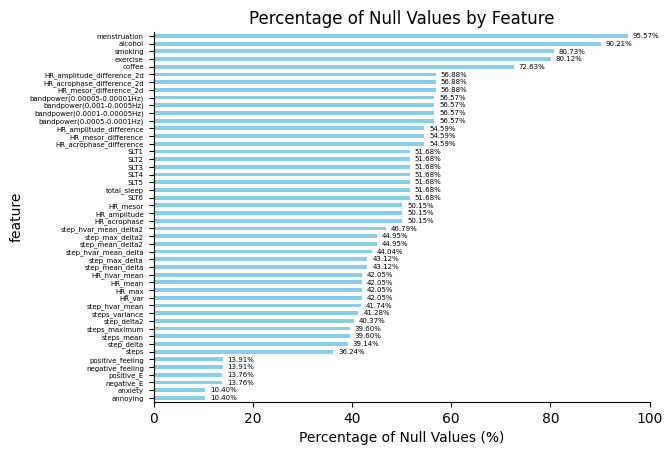

In [9]:
plt.figure(figsize=(5, 10))  # Adjusted to make it thinner horizontally and longer vertically
colors = ['skyblue'] * len(null_value_analysis)
ax = null_value_analysis.sort_values('null%', ascending=True).plot(
	kind='barh', x='feature', y='null%', color=colors, legend=False, width=0.5  # Reduced bar width to increase gaps
)
plt.title("Percentage of Null Values by Feature")
plt.xlabel("Percentage of Null Values (%)")
plt.xlim(0, 100)  # Set the x-axis limit to 0-100
# get rid of the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Adjust y-axis labels for better visibility
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5, rotation=0, ha='right')

# Add labels with values to the right of each bar
for p in ax.patches:
	value = f"{p.get_width():.2f}%"
	ax.annotate(value,
				(p.get_width() + 1, p.get_y() + p.get_height() / 2),
				ha='left', va='center', fontsize=5, color='black', xytext=(0, 0),
				textcoords='offset points')

plt.show()

## 🤯 | Patient-level Analysis

**Description**
- `n_entries`: Number of entries per patient
- `n_valid_3_entries`: Number of valid (3 prior consecutive days of data) entries per patient
- `n_valid_2_entries`: Number of valid (2 prior consecutive days of data) entries per patient
- `n_valid_1_entries`: Number of valid (1 prior consecutive days of data) entries per patient
- `n_panic`: Number of panic events per patient
- `max_severity`: Maximum panic severity experienced by patient
- `min_severity`: Minimum panic severity experienced by patient
- `mean_severity`: Average panic severity experienced by patient
- `n_dailylog`: Number of daily log entries per patient
- `n_lifelog`: Number of life log entries per patient
- `n_questionnaire`: Number of questionnaire entries per patient
- `sum_dtype`: Number of data (by group) per patient
- `mean_dtype`: Average number of data types per entry per patient

In [10]:
agg_matrix = [
	('n_entries', 'entry_id', 'count'),
	('n_valid_3_entries', 'valid_entry_3', 'sum'),
	('n_valid_2_entries', 'valid_entry_2', 'sum'),
	('n_valid_1_entries', 'valid_entry_1', 'sum'),
	('n_panic', 'panic_label', 'sum'),
    ('max_severity', 'severity', 'max'),
	('min_severity', 'severity', 'min'),
	('mean_severity', 'severity', 'mean'),
	('n_dailylog', 'dailylog_data', 'sum'),
	('n_lifelog', 'lifelog_data', 'sum'),
	('n_questionnaire', 'questionnaire_data', 'sum'),
	('sum_dtype', 'dtype_n', 'sum'),
	('mean_dtype', 'dtype_n', 'mean'),
]
patient_analysis_data = create_empty_df()
metadata_proc = metadata[metadata['entry_id'].isin(unique_proc_entries_raw)]
patient_analysis_data = aggregate_by_column(metadata_proc, 'ID', agg_matrix)
# map age to patient_analysis_data using ID and demography_data
patient_analysis_data = patient_analysis_data.merge(demography_data[['ID', 'age']], on='ID', how='left')

display(patient_analysis_data.head(5))
save_as_csv(patient_analysis_data, OUTPUT_PATH, f"panic_patient_analysis{file_desc}")

,ID,n_entries,n_valid_3_entries,n_valid_2_entries,n_valid_1_entries,n_panic,max_severity,min_severity,mean_severity,n_dailylog,n_lifelog,n_questionnaire,sum_dtype,mean_dtype,age
0,PXPN_10006,6,4,5,6,0,NaN,NaN,NaN,4,6,0,10,1.67,32
1,PXPN_10007,8,4,5,7,0,NaN,NaN,NaN,6,8,0,14,1.75,38
2,PXPN_10008,6,6,6,6,0,NaN,NaN,NaN,2,6,0,8,1.33,38
3,PXPN_10009,2,0,0,1,0,NaN,NaN,NaN,2,2,0,4,2.00,28
4,PXPN_10011,6,3,4,5,0,NaN,NaN,NaN,6,6,1,13,2.17,41


DEBUG - (text_utils.py) save_as_csv: Saved panic_patient_analysis.csv to C:\Users\cyshi\OneDrive\Documents\GitHub\Panic-Project-CYS\_tmp\analysis


WindowsPath('C:/Users/cyshi/OneDrive/Documents/GitHub/Panic-Project-CYS/_tmp/analysis/panic_patient_analysis.csv')

In [11]:
patient_analysis_data_total = create_empty_df()
unique_proc_ids = proc_data_pre['ID'].unique()
metadata_proc_total = metadata[metadata['ID'].isin(unique_proc_ids)]
patient_analysis_data_total = aggregate_by_column(metadata_proc_total, 'ID', agg_matrix)
patient_analysis_data_total = patient_analysis_data_total.merge(demography_data[['ID', 'age']], on='ID', how='left')

display(patient_analysis_data_total.head(5))
save_as_csv(patient_analysis_data_total, OUTPUT_PATH, f"panic_patient_analysis_total{file_desc}")

,ID,n_entries,n_valid_3_entries,n_valid_2_entries,n_valid_1_entries,n_panic,max_severity,min_severity,mean_severity,n_dailylog,n_lifelog,n_questionnaire,sum_dtype,mean_dtype,age
0,PXPN_10006,28,18,21,24,3,2.0,1.0,1.33,22,28,1,51,1.82,32
1,PXPN_10007,28,16,20,24,4,2.0,1.0,1.25,20,28,1,49,1.75,38
2,PXPN_10008,27,18,21,24,3,2.0,1.0,1.67,20,27,1,48,1.78,38
3,PXPN_10009,28,17,19,22,5,4.0,1.0,2.60,28,28,1,57,2.04,28
4,PXPN_10011,28,14,18,23,4,4.0,1.0,2.50,24,28,1,53,1.89,41


DEBUG - (text_utils.py) save_as_csv: Saved panic_patient_analysis_total.csv to C:\Users\cyshi\OneDrive\Documents\GitHub\Panic-Project-CYS\_tmp\analysis


WindowsPath('C:/Users/cyshi/OneDrive/Documents/GitHub/Panic-Project-CYS/_tmp/analysis/panic_patient_analysis_total.csv')

## 🤯🕳️ | Patient-level Null Value Analysis

Produces csv file of the percentage of the Null values for each feature in Daily Log, and Life Log for each patient

In [12]:
agg_matrix = [('n_entries', 'entry_id', 'count')]

for col in null_analysis_features:
    agg_matrix.append((col, col, 'count'))

patient_null_analysis_data = create_empty_df()
patient_null_analysis_data = aggregate_by_column(pre_data, 'ID', agg_matrix)

for col in null_analysis_features:
    patient_null_analysis_data[col] = (patient_null_analysis_data['n_entries'] - patient_null_analysis_data[col]) / patient_null_analysis_data['n_entries'] * 100

patient_null_analysis_data['lifelog_avg'] = patient_null_analysis_data[features_dict['lifelog']].mean(axis=1)
patient_null_analysis_data['lifelog_HR_avg'] = patient_null_analysis_data[features_dict['lifelog_HR']].mean(axis=1)
patient_null_analysis_data['lifelog_steps_avg'] = patient_null_analysis_data[features_dict['lifelog_steps']].mean(axis=1)
patient_null_analysis_data['lifelog_sleep_avg'] = patient_null_analysis_data[features_dict['lifelog_sleep']].mean(axis=1)

null_analysis_features_dailylog = [f for f in features_dict['dailylog'] if f != 'severity']
patient_null_analysis_data['dailylog_avg_avg'] = patient_null_analysis_data[null_analysis_features_dailylog].mean(axis=1)
patient_null_analysis_data['dailylog_mood_avg'] = patient_null_analysis_data[features_dict['mood']].mean(axis=1)
patient_null_analysis_data['dailylog_life_avg'] = patient_null_analysis_data[features_dict['dailylog_life']].mean(axis=1)

patient_null_analysis_data['total_avg'] = patient_null_analysis_data[features_dict['lifelog'] + null_analysis_features_dailylog].mean(axis=1)

display(patient_null_analysis_data.head(5))
save_as_csv(patient_null_analysis_data, OUTPUT_PATH, f"panic_patient_null_analysis{file_desc}")

,ID,n_entries,HR_var,HR_max,HR_mean,HR_hvar_mean,HR_acrophase,HR_amplitude,HR_mesor,HR_acrophase_difference,...,anxiety,annoying,lifelog_avg,lifelog_HR_avg,lifelog_steps_avg,lifelog_sleep_avg,dailylog_avg_avg,dailylog_mood_avg,dailylog_life_avg,total_avg
0,PXPN_10006,28,10.71,10.71,10.71,10.71,92.86,92.86,92.86,96.43,...,21.43,21.43,41.89,75.42,3.30,32.14,56.17,27.38,90.71,45.16
1,PXPN_10007,28,0.00,0.00,0.00,0.00,96.43,96.43,96.43,100.00,...,28.57,28.57,54.54,75.00,3.30,100.00,62.34,45.24,82.86,56.32
2,PXPN_10008,27,0.00,0.00,0.00,0.00,81.48,81.48,81.48,96.30,...,25.93,25.93,51.45,68.19,3.42,100.00,62.63,37.04,93.33,54.01
3,PXPN_10009,28,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,0.00,0.00,67.57,100.00,7.69,100.00,35.39,0.00,77.86,60.19
4,PXPN_10010,28,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,17.86,17.86,66.51,100.00,4.67,100.00,40.58,20.24,65.00,60.57


DEBUG - (text_utils.py) save_as_csv: Saved panic_patient_null_analysis.csv to C:\Users\cyshi\OneDrive\Documents\GitHub\Panic-Project-CYS\_tmp\analysis


WindowsPath('C:/Users/cyshi/OneDrive/Documents/GitHub/Panic-Project-CYS/_tmp/analysis/panic_patient_null_analysis.csv')

# 📒 | Reports

In [13]:
from library.matplotlib_utils import plot_histogram_of_counts

## Overview

In [14]:
unique_ids =  pre_data['ID'].unique()
print(f"Total number of unique IDs in pre_data_filled: {len(unique_ids)}")
print(f"Total number of entries in pre_data_filled: {len(pre_data)}")
panic_entries = pre_data[pre_data['panic_label'] == 1]
print(f"Total number of panic entries in pre_data_filled: {len(panic_entries)}")

Total number of unique IDs in pre_data_filled: 279
Total number of entries in pre_data_filled: 19516
Total number of panic entries in pre_data_filled: 866


In [15]:
filled_entry_ids = pre_data['entry_id'].unique()
print(f"Total number of daily log entries: {metadata[metadata['dailylog_data'] == 1].shape[0]} / {len(filled_entry_ids)} ({metadata[metadata['dailylog_data'] == 1].shape[0] / len(filled_entry_ids) * 100:.2f}%)")
print(f"Total number of life log entries: {metadata[metadata['lifelog_data'] == 1].shape[0]} / {len(filled_entry_ids)} ({metadata[metadata['lifelog_data'] == 1].shape[0] / len(filled_entry_ids) * 100:.2f}%)")
print(f"Total number of questionnaire entries: {metadata[metadata['questionnaire_data'] == 1].shape[0]} / {len(filled_entry_ids)} ({metadata[metadata['questionnaire_data'] == 1].shape[0] / len(filled_entry_ids) * 100:.2f}%)")

Total number of daily log entries: 14968 / 19516 (76.70%)
Total number of life log entries: 12501 / 19516 (64.06%)
Total number of questionnaire entries: 643 / 19516 (3.29%)


In [16]:
panic_patients = metadata[metadata['panic_label'] == 1]['ID'].unique()
print(f"Total number of patients with panic events: {len(panic_patients)}")

Total number of patients with panic events: 110


## 🗒️ | Entry-level Analysis

### Data Groups

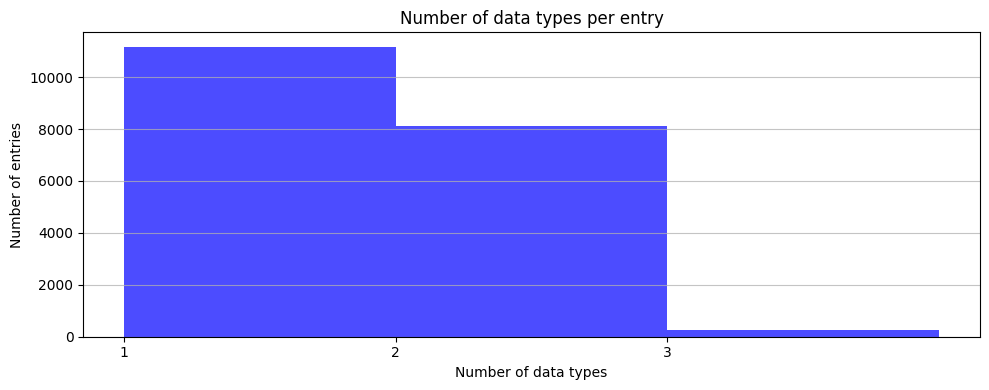

Number of entries with 1 data type: 11165 (57.21%)
Number of entries with 2 data types: 8106 (41.54%)
Number of entries with 3 data types: 245 (1.26%)


In [17]:
plot_histogram_of_counts(metadata['dtype_n'], title='Number of data types per entry', xlabel='Number of data types', ylabel='Number of entries', zero_start=False, bins_step=1)
print(f"Number of entries with 1 data type: {metadata[metadata['dtype_n'] == 1].shape[0]} ({metadata[metadata['dtype_n'] == 1].shape[0] / metadata.shape[0] * 100:.2f}%)")
print(f"Number of entries with 2 data types: {metadata[metadata['dtype_n'] == 2].shape[0]} ({metadata[metadata['dtype_n'] == 2].shape[0] / metadata.shape[0] * 100:.2f}%)")
print(f"Number of entries with 3 data types: {metadata[metadata['dtype_n'] == 3].shape[0]} ({metadata[metadata['dtype_n'] == 3].shape[0] / metadata.shape[0] * 100:.2f}%)")

### Valid Entries

In [18]:
print(f"Total number of valid entries (3 days): {metadata['valid_entry_3'].sum()} ({metadata['valid_entry_3'].mean() * 100:.2f}%)")
print(f"Total number of valid entries (2 days): {metadata['valid_entry_2'].sum()} ({metadata['valid_entry_2'].mean() * 100:.2f}%)")
print(f"Total number of valid entries (1 day): {metadata['valid_entry_1'].sum()} ({metadata['valid_entry_1'].mean() * 100:.2f}%)")

Total number of valid entries (3 days): 14332 (73.44%)
Total number of valid entries (2 days): 15449 (79.16%)
Total number of valid entries (1 day): 17026 (87.24%)


In [19]:
panic_n = pre_data[pre_data['panic_label'] == 1].shape[0]
print(f"Total number of panic events (panic_label=1): {panic_n}")
valid_panic_events_3 = metadata[(metadata['valid_entry_3'] == 1) & (metadata['dbp'] == 0)].shape[0]
print(f"Total number of valid panic events (n_prior_data >= 3 days): {valid_panic_events_3} ({valid_panic_events_3 / panic_n * 100:.2f}%)")
valid_panic_events_2 = metadata[(metadata['valid_entry_2'] == 1) & (metadata['dbp'] == 0)].shape[0]
print(f"Total number of valid panic events (n_prior_data >= 2 days): {valid_panic_events_2} ({valid_panic_events_2 / panic_n * 100:.2f}%)")
valid_panic_events_1 = metadata[(metadata['valid_entry_1'] == 1) & (metadata['dbp'] == 0)].shape[0]
print(f"Total number of valid panic events (n_prior_data >= 1 day): {valid_panic_events_1} ({valid_panic_events_1 / panic_n * 100:.2f}%)")

Total number of panic events (panic_label=1): 866
Total number of valid panic events (n_prior_data >= 3 days): 266 (30.72%)
Total number of valid panic events (n_prior_data >= 2 days): 327 (37.76%)
Total number of valid panic events (n_prior_data >= 1 day): 464 (53.58%)


In [20]:
one_dbp = metadata[metadata['dbp'] == 1]
print(f"Total number of entries with dbp=1: {one_dbp.shape[0]} ({one_dbp.shape[0] / metadata.shape[0] * 100:.2f}%)")
two_dvp = metadata[metadata['dbp'] == 2]
print(f"Total number of entries with dbp=2: {two_dvp.shape[0]} ({two_dvp.shape[0] / metadata.shape[0] * 100:.2f}%)")

Total number of entries with dbp=1: 464 (2.38%)
Total number of entries with dbp=2: 350 (1.79%)


## 🤢 | Patient-level Analysis

In [21]:
pre_data_ids = pre_data['ID'].unique()

### Patient-level Valid Entries

Number of patients with > 100 entries: 0 / 279 (0.00%)
Number of patients with <= 100 entries: 71 / 279 (25.45%)
Number of patients with > 30 entries: 4 / 279 (1.43%)
Number of patients with <= 30 entries: 67 / 279 (24.01%)


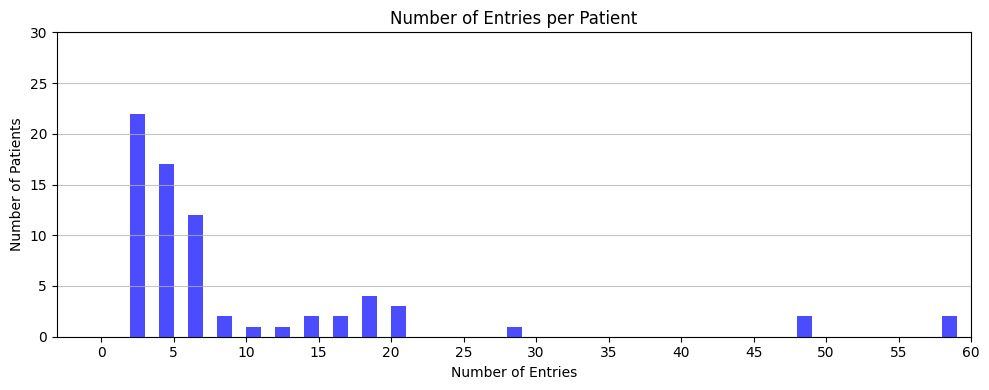

In [22]:
print(f"Number of patients with > 100 entries: {patient_analysis_data[patient_analysis_data['n_entries'] > 100].shape[0]} / {len(pre_data_ids)} ({patient_analysis_data[patient_analysis_data['n_entries'] > 100].shape[0] / len(pre_data_ids) * 100:.2f}%)")
print(f"Number of patients with <= 100 entries: {patient_analysis_data[patient_analysis_data['n_entries'] <= 100].shape[0]} / {len(pre_data_ids)} ({patient_analysis_data[patient_analysis_data['n_entries'] <= 100].shape[0] / len(pre_data_ids) * 100:.2f}%)")
print(f"Number of patients with > 30 entries: {patient_analysis_data[patient_analysis_data['n_entries'] > 30].shape[0]} / {len(pre_data_ids)} ({patient_analysis_data[patient_analysis_data['n_entries'] > 30].shape[0] / len(pre_data_ids) * 100:.2f}%)")
print(f"Number of patients with <= 30 entries: {patient_analysis_data[patient_analysis_data['n_entries'] <= 30].shape[0]} / {len(pre_data_ids)} ({patient_analysis_data[patient_analysis_data['n_entries'] <= 30].shape[0] / len(pre_data_ids) * 100:.2f}%)")
plot_histogram_of_counts(patient_analysis_data['n_entries'], title='Number of Entries per Patient',
                         xlabel='Number of Entries', ylabel='Number of Patients', bins_step=5, exclude_zero=True, xmax=60, ymax=30)

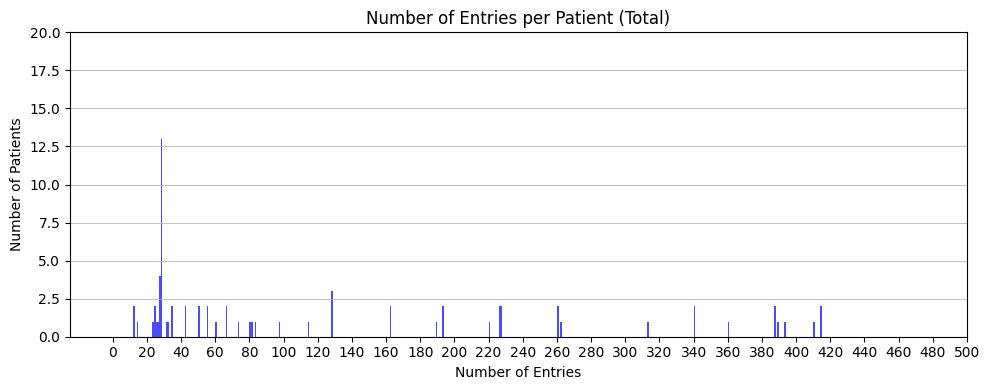

In [23]:
plot_histogram_of_counts(patient_analysis_data_total['n_entries'], title='Number of Entries per Patient (Total)',
                         xlabel='Number of Entries', ylabel='Number of Patients', bins_step=20, exclude_zero=True, xmax=500, ymax=20)

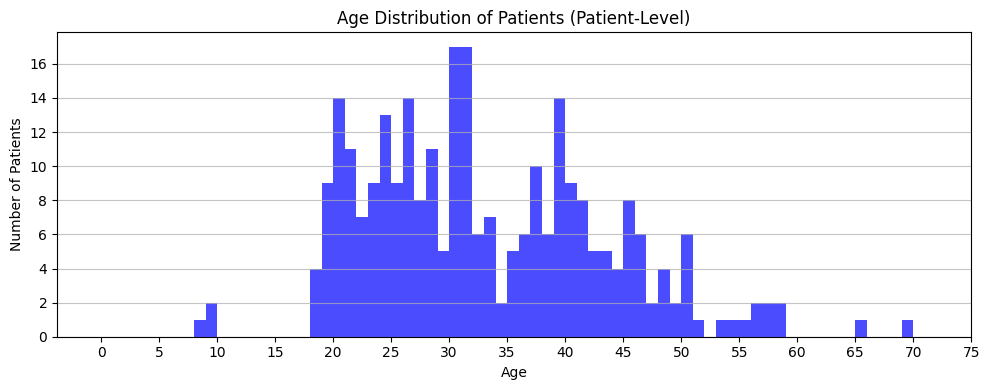

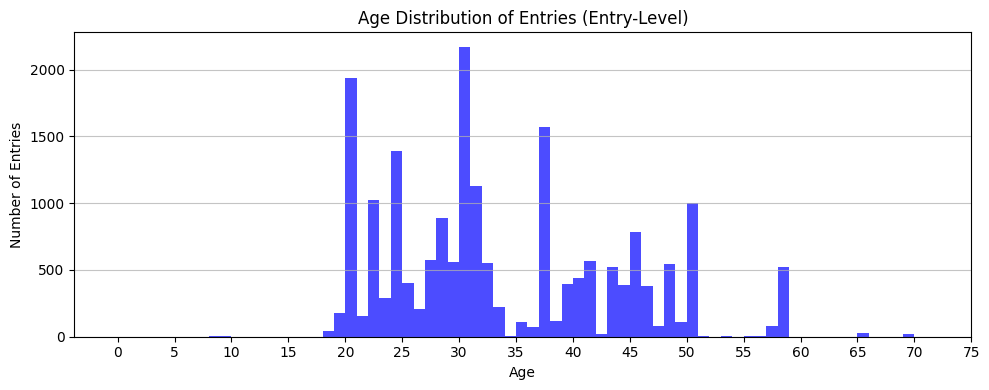

In [24]:
unique_ids_total = pre_data['ID'].unique()
demography_data_age = demography_data[demography_data['ID'].isin(unique_ids_total)]
plot_histogram_of_counts(demography_data_age['age'], title='Age Distribution of Patients (Patient-Level)',
						 xlabel='Age', ylabel='Number of Patients', bins_step=5, exclude_zero=True, xmax= 75)
pre_data_age = pre_data.merge(demography_data[['ID', 'age']], on='ID', how='left')
plot_histogram_of_counts(pre_data_age['age'], title='Age Distribution of Entries (Entry-Level)',
						 xlabel='Age', ylabel='Number of Entries', bins_step=5, exclude_zero=True, xmax= 75)

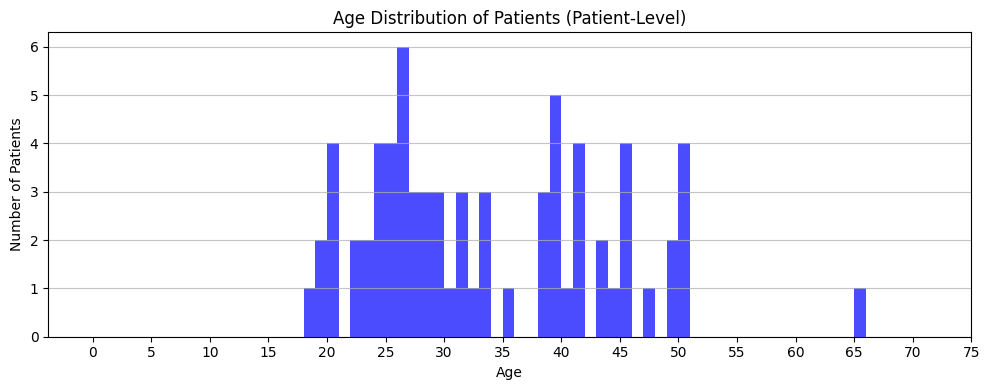

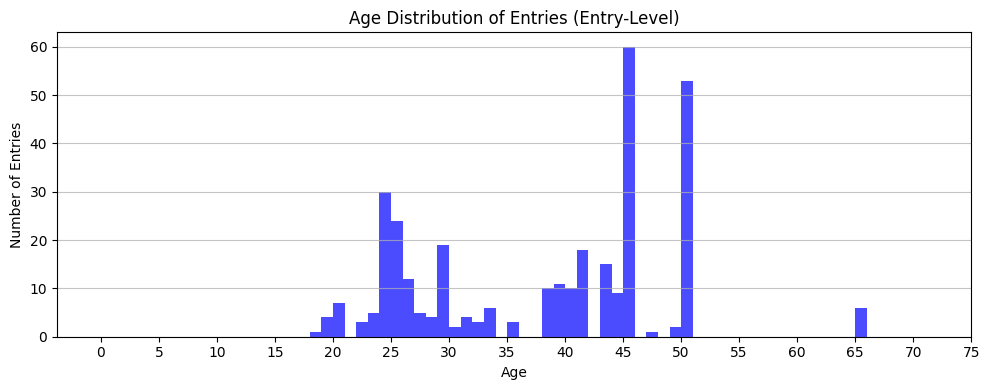

In [26]:
unique_ids_total = proc_data['ID'].unique()
demography_data_age = demography_data[demography_data['ID'].isin(unique_ids_total)]
plot_histogram_of_counts(demography_data_age['age'], title='Age Distribution of Patients (Patient-Level)',
						 xlabel='Age', ylabel='Number of Patients', bins_step=5, exclude_zero=True, xmax= 75)
plot_histogram_of_counts(proc_data['age'], title='Age Distribution of Entries (Entry-Level)',
						 xlabel='Age', ylabel='Number of Entries', bins_step=5, exclude_zero=True, xmax= 75)

### Patient-level Data Group Analysis

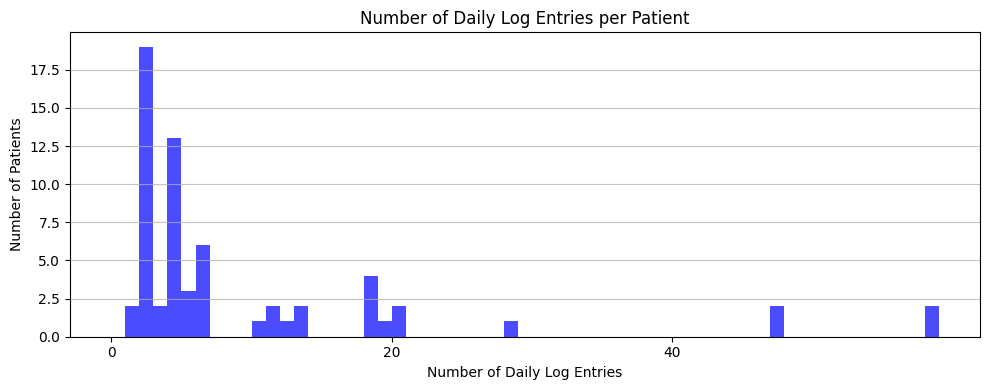

Number of patients with no daily log entries: 8 / 279


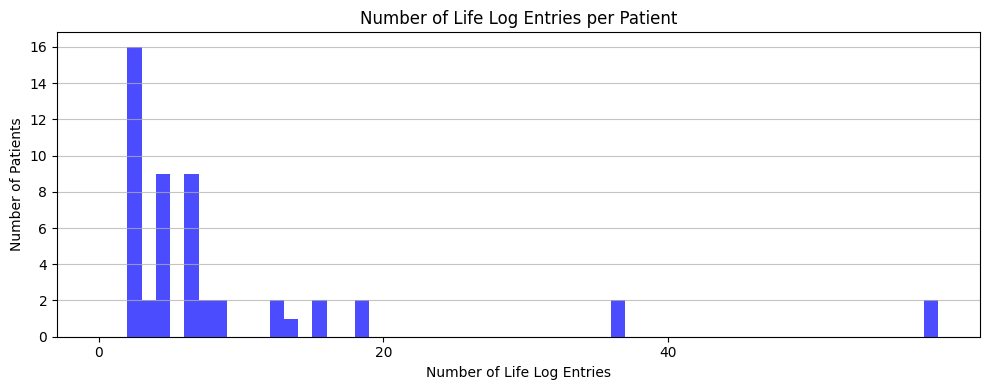

Number of patients with no life log entries: 20 / 279


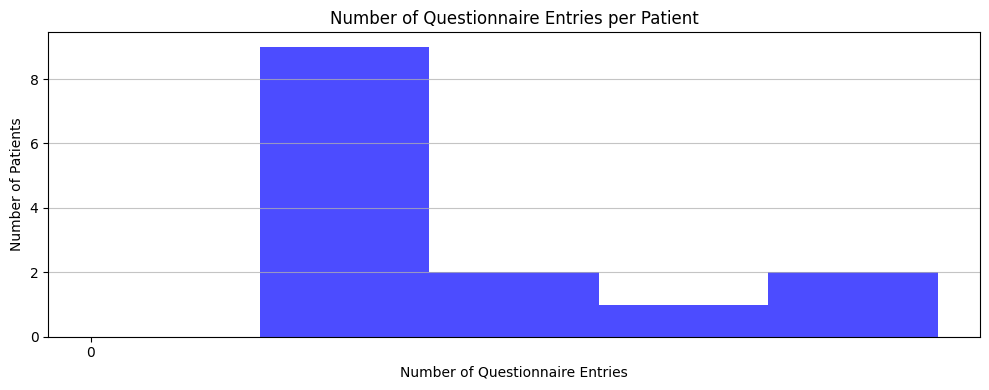

Number of patients with no questionnaire entries: 57 / 279


In [ ]:
plot_histogram_of_counts(patient_analysis_data['n_dailylog'], title='Number of Daily Log Entries per Patient',
						 xlabel='Number of Daily Log Entries', ylabel='Number of Patients', bins_step=20, exclude_zero=True)
print(f"Number of patients with no daily log entries: {patient_analysis_data[patient_analysis_data['n_dailylog'] == 0].shape[0]} / {len(pre_data_ids)}")
plot_histogram_of_counts(patient_analysis_data['n_lifelog'], title='Number of Life Log Entries per Patient',
						 xlabel='Number of Life Log Entries', ylabel='Number of Patients', bins_step=20, exclude_zero=True)
print(f"Number of patients with no life log entries: {patient_analysis_data[patient_analysis_data['n_lifelog'] == 0].shape[0]} / {len(pre_data_ids)}")
plot_histogram_of_counts(patient_analysis_data['n_questionnaire'], title='Number of Questionnaire Entries per Patient',
						 xlabel='Number of Questionnaire Entries', ylabel='Number of Patients', bins_step=20, exclude_zero=True)
print(f"Number of patients with no questionnaire entries: {patient_analysis_data[patient_analysis_data['n_questionnaire'] == 0].shape[0]} / {len(pre_data_ids)}")

In [ ]:
metadata_panic = metadata[metadata['panic_label'] == 1].copy()
print(f"Number of panic events in preprocessed data: {metadata_panic.shape[0]}")
agg_matrix = [
	('valid_entries_3', 'valid_entry_3', 'sum'),
	('valid_entries_2', 'valid_entry_2', 'sum'),
	('valid_entries_1', 'valid_entry_1', 'sum'),
]
agg_metadata_panic = aggregate_by_column(metadata_panic, 'ID', agg_matrix)

print(f"Number of valid panic entries (valid_entry_3): {agg_metadata_panic['valid_entries_3'].sum()}")
print(f"Number of valid panic entries (valid_entry_2): {agg_metadata_panic['valid_entries_2'].sum()}")
print(f"Number of valid panic entries (valid_entry_1): {agg_metadata_panic['valid_entries_1'].sum()}")
print("--------------------------------------------------------")
print(f"Number of patients with valid panic entries (valid_entry_3): {agg_metadata_panic[agg_metadata_panic['valid_entries_3'] > 0].shape[0]}")
print(f"Number of patients with valid panic entries (valid_entry_2): {agg_metadata_panic[agg_metadata_panic['valid_entries_2'] > 0].shape[0]}")
print(f"Number of patients with valid panic entries (valid_entry_1): {agg_metadata_panic[agg_metadata_panic['valid_entries_1'] > 0].shape[0]}")

Number of panic events in preprocessed data: 866
Number of valid panic entries (valid_entry_3): 266
Number of valid panic entries (valid_entry_2): 327
Number of valid panic entries (valid_entry_1): 464
--------------------------------------------------------
Number of patients with valid panic entries (valid_entry_3): 65
Number of patients with valid panic entries (valid_entry_2): 71
Number of patients with valid panic entries (valid_entry_1): 83
